In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files #para fazer donwload de figuras geradas aqui no google colab

#Importando os pacotes que vou utilizar na análise abaixo

In [2]:
df = pd.read_csv('https://query.data.world/s/tstat4gakq4viuuxzxqzmq2er5hb4b?dws=00000')
df
#Utilizando o pandas eu importo o arquivo CSV que será utilizado diretamente do link onde está hospedada

,Unnamed: 0,X,Cidade,Registros,Ano,Mês,Região,Estado
0,1,1,Brasiléia,6,2015,Janeiro,Todas,Acre
1,2,2,Bujari,1,2015,Janeiro,Todas,Acre
2,3,3,Capixaba,2,2015,Janeiro,Todas,Acre
3,4,4,Cruzeiro do Sul,74,2015,Janeiro,Todas,Acre
4,5,5,Epitaciolândia,3,2015,Janeiro,Todas,Acre
...,...,...,...,...,...,...,...,...
412369,412370,69909,Tocantínia,4,2022,Dezembro,Todas,Tocantins
412370,412371,69910,Tocantinópolis,6,2022,Dezembro,Todas,Tocantins
412371,412372,69911,Tupiratins,2,2022,Dezembro,Todas,Tocantins
412372,412373,69912,Wanderlândia,2,2022,Dezembro,Todas,Tocantins


In [3]:
df = df.drop(['Unnamed: 0', 'Região', 'X'], axis = 1)

#Exclui a primeira coluna, pois é exatamente igual ao índice

In [4]:
colunas = list(df.columns)
colunas

#Crio uma variável com os nomes das colunas para facilitar a visualização deles e facilitar o acesso em momentos posteriores


['Cidade', 'Registros', 'Ano', 'Mês', 'Estado']

In [5]:
df.duplicated().sum()

# código para verificar se existe algum valor duplicado no arquivo

0

In [6]:
df.isna().sum()

#Aqui eu verifico se há algum dado ausente

Cidade       0
Registros    0
Ano          0
Mês          0
Estado       0
dtype: int64

In [7]:
unico = df.nunique().sort_values()

# Esse código determina o tipo de dado de cada uma das variáveis do banco de dados.

unico = pd.DataFrame(unico.values, index = unico.index, columns = ['NUniques'])

# Aqui eu atribuo informações sobre o tipo de dado das variáveis ao DataFrame.

unico['dtypes'] = df.dtypes

#E por fim eu verifico quantos valores únicos tem para cada coluna

unico

,NUniques,dtypes
Ano,8,int64
Mês,12,object
Estado,27,object
Registros,1551,int64
Cidade,4938,object


In [8]:
data = pd.DataFrame(columns = ['Estado', 'Total_geral'])

#criando um dataset para análises estatisticas. Utilizando a coluna estado e criando uma coluna nova "Total_geral" para armazenar resultados gerais de morte para cada estado.

In [9]:
listado = []
listotal=[]
tot = df[['Estado','Registros']]
for estado in df['Estado'].unique():
  loc = tot[tot['Estado'] == estado]
  #tot = loc['Registros'].sum()
  listado.append(estado)
  listotal.append(loc['Registros'].sum() )

# Criei duas variáveis que serão utilizadas para armazenar os dados do loop a seguir.
#Separei um dataframe somente com as colunas de estado e registros de morte e fiz um loop para identificar o total de registros de morte para cada estado

In [10]:
data['Estado'] = listado
data['Total_geral']=listotal

#Preenchi o dataset criado com o resultado do loop

In [11]:
df['Total_mensal_por_ano']= df.groupby(['Estado', 'Ano','Mês'])['Registros'].transform('sum')

#adicionei uma coluna na tabela inicial com valores de total geral de morte por estado por mês para cada ano

In [12]:
df

,Cidade,Registros,Ano,Mês,Estado,Total_mensal_por_ano
0,Brasiléia,6,2015,Janeiro,Acre,289
1,Bujari,1,2015,Janeiro,Acre,289
2,Capixaba,2,2015,Janeiro,Acre,289
3,Cruzeiro do Sul,74,2015,Janeiro,Acre,289
4,Epitaciolândia,3,2015,Janeiro,Acre,289
...,...,...,...,...,...,...
412369,Tocantínia,4,2022,Dezembro,Tocantins,586
412370,Tocantinópolis,6,2022,Dezembro,Tocantins,586
412371,Tupiratins,2,2022,Dezembro,Tocantins,586
412372,Wanderlândia,2,2022,Dezembro,Tocantins,586


In [13]:
Ano2022 = df[df['Ano']==2022]

# separando somente valores do ano de 2022


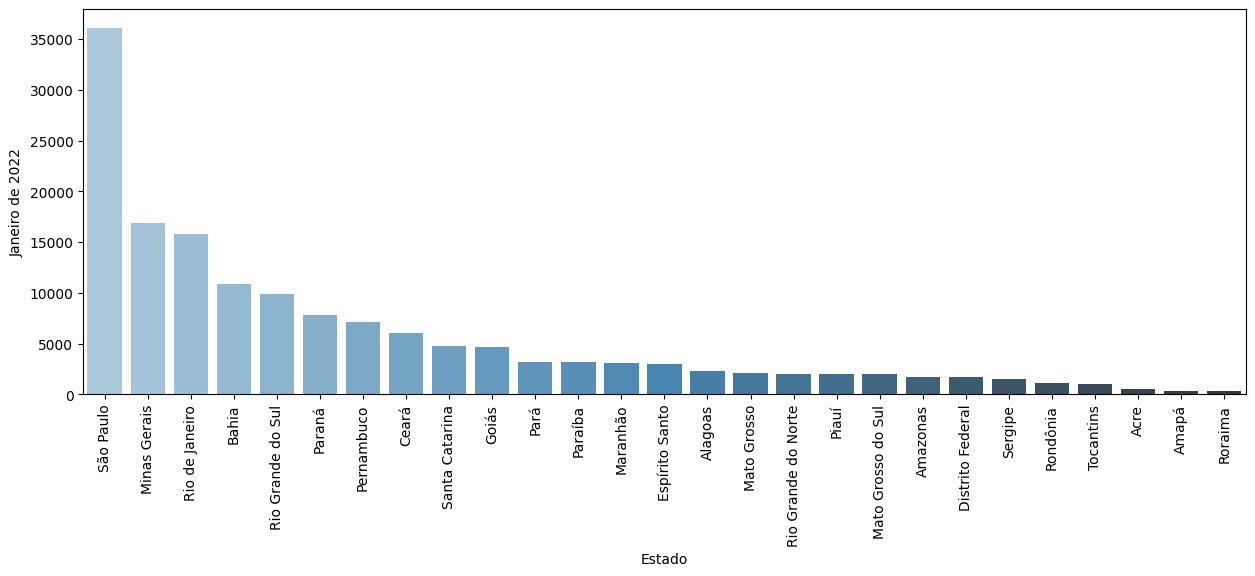

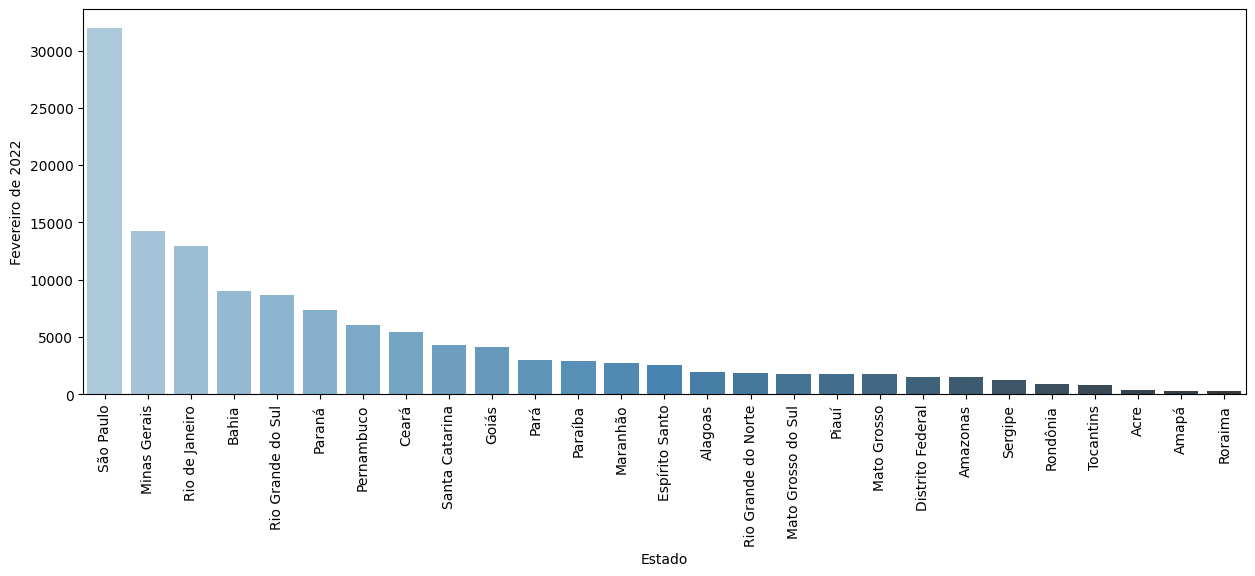

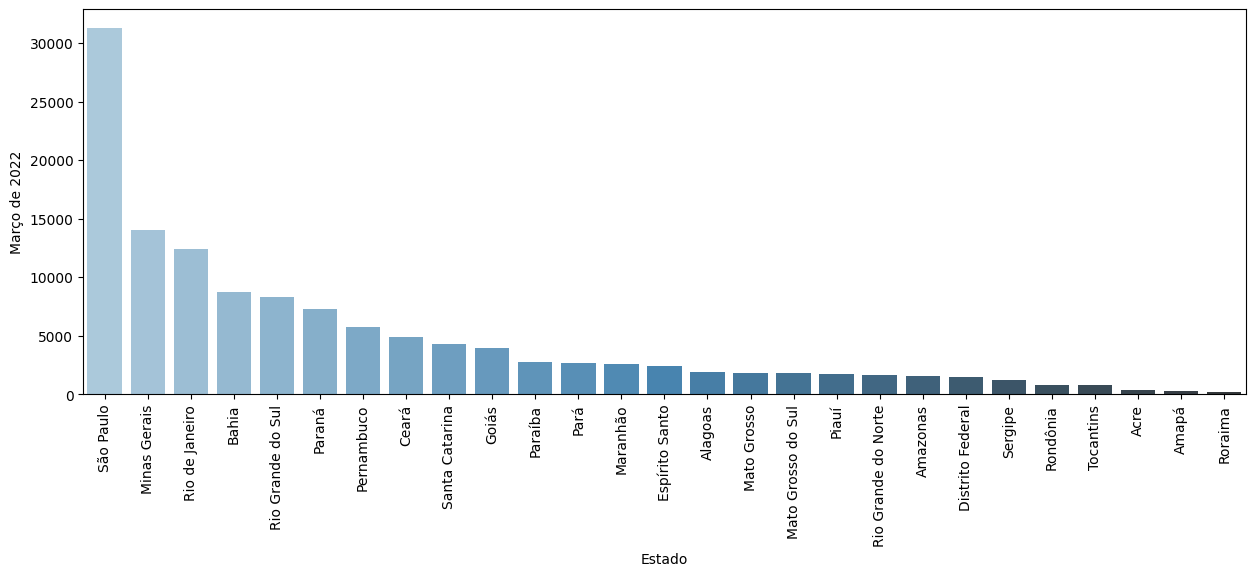

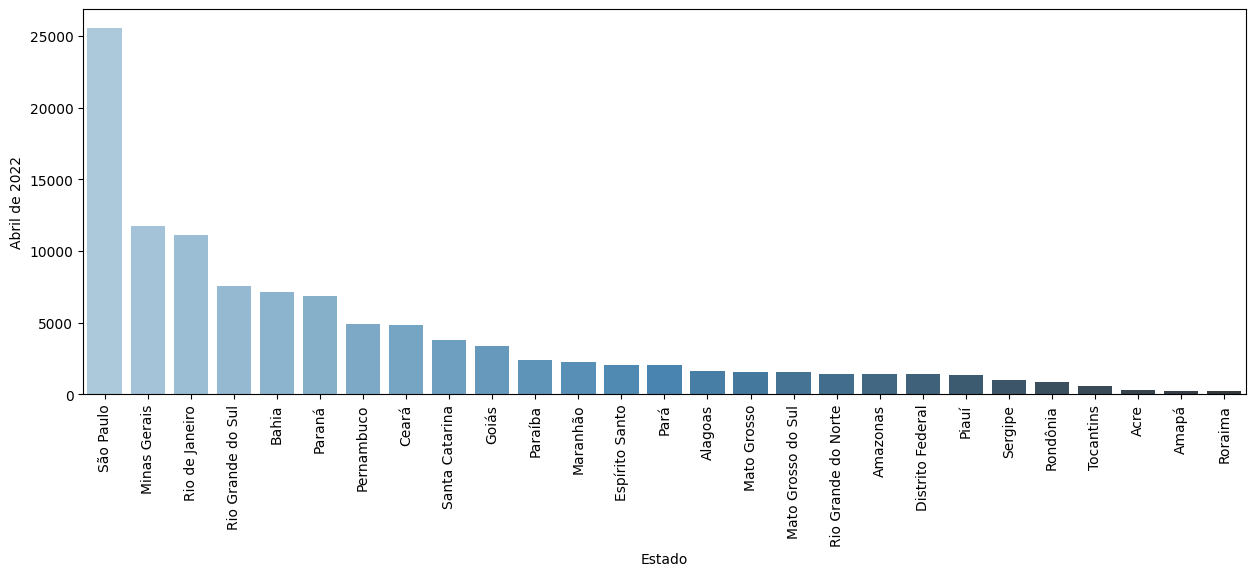

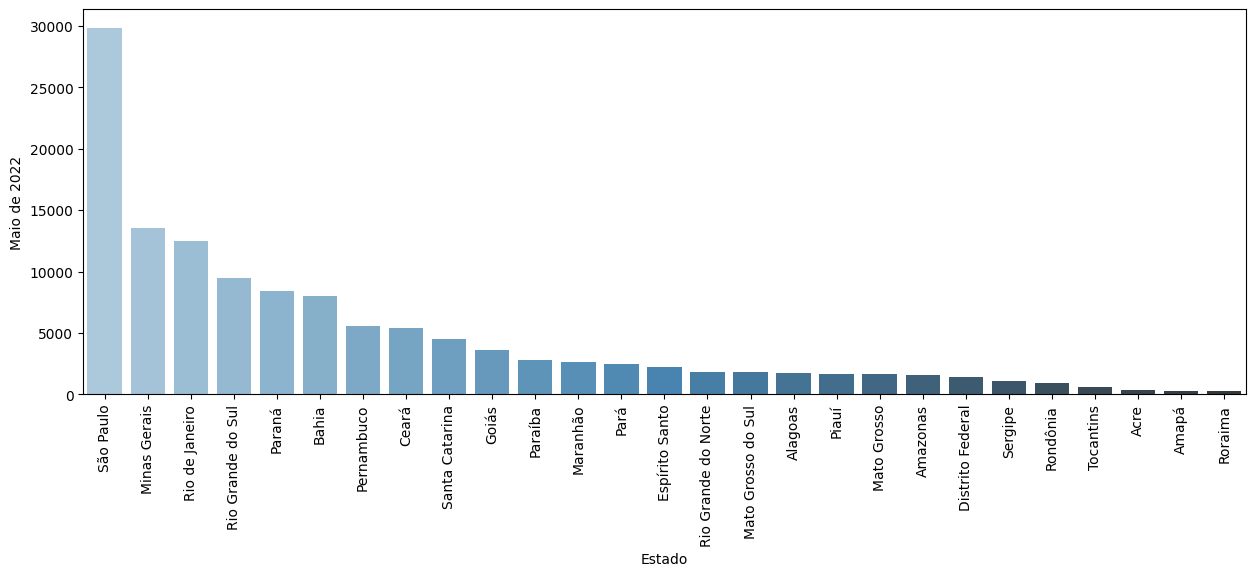

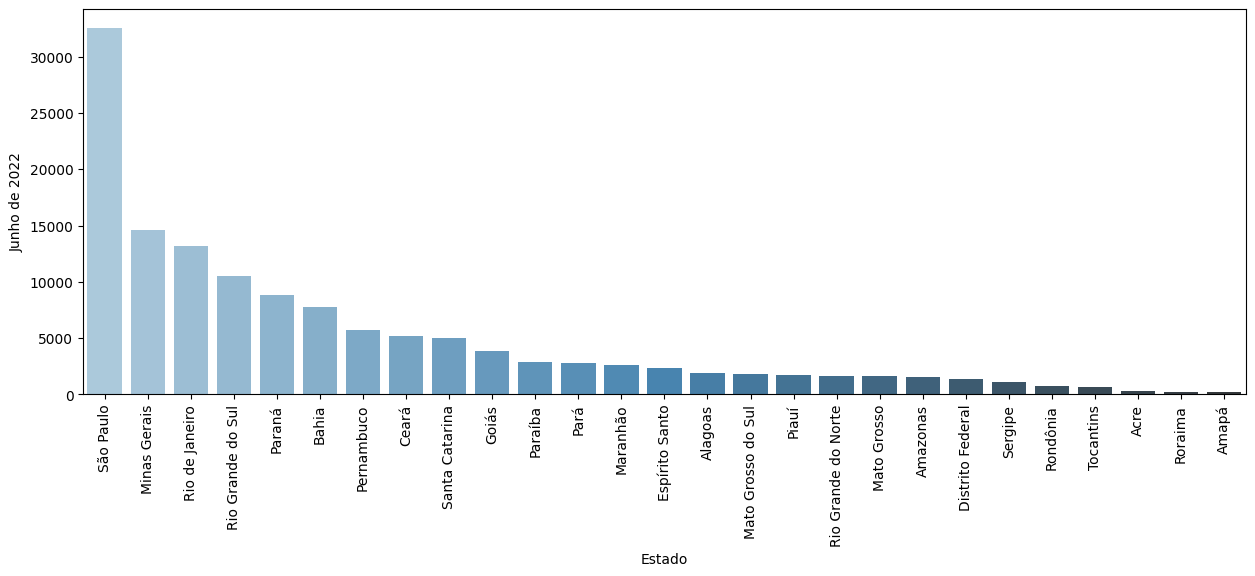

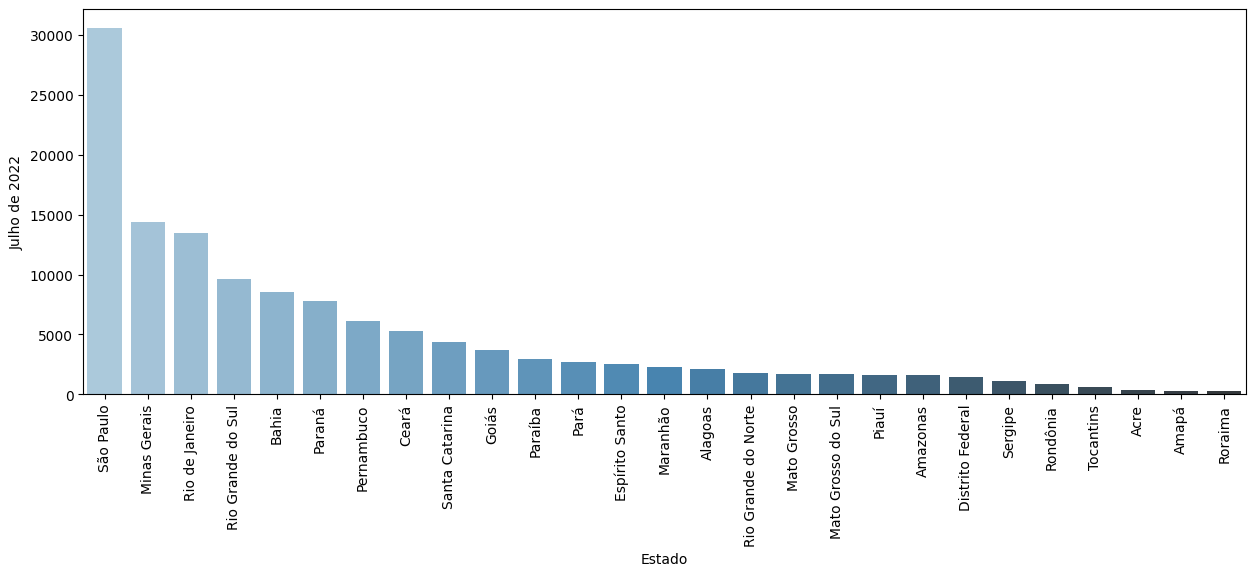

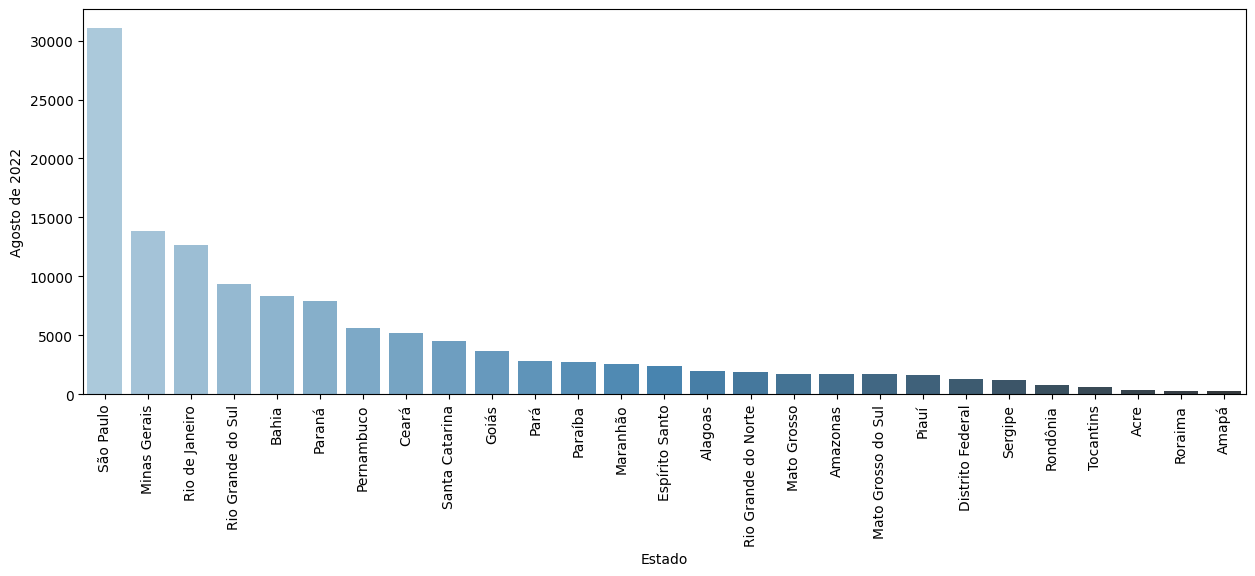

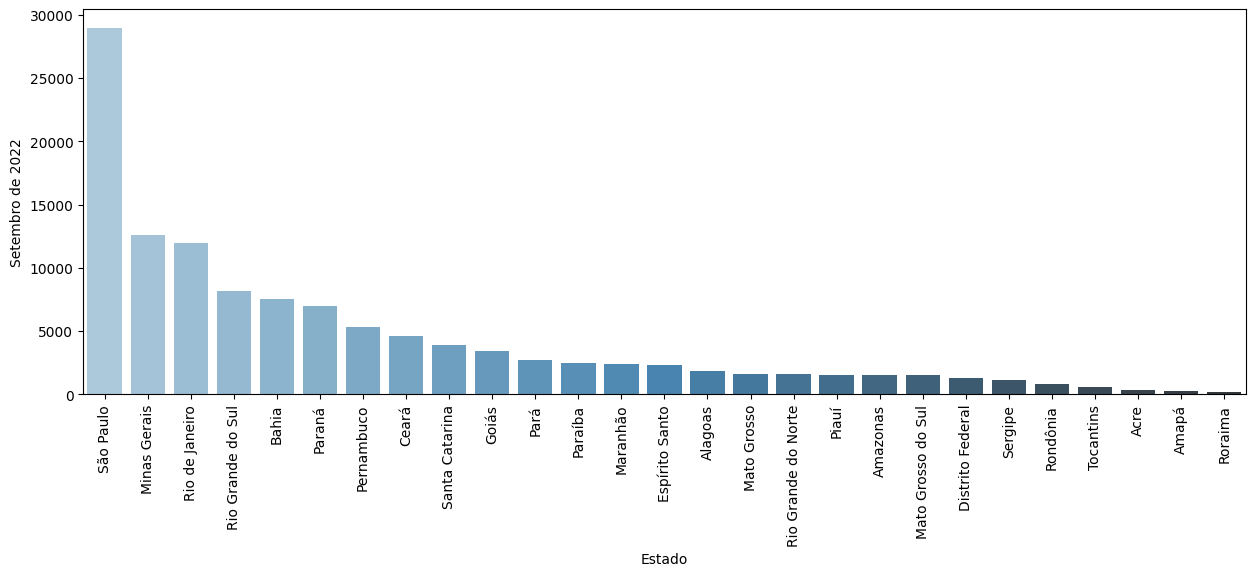

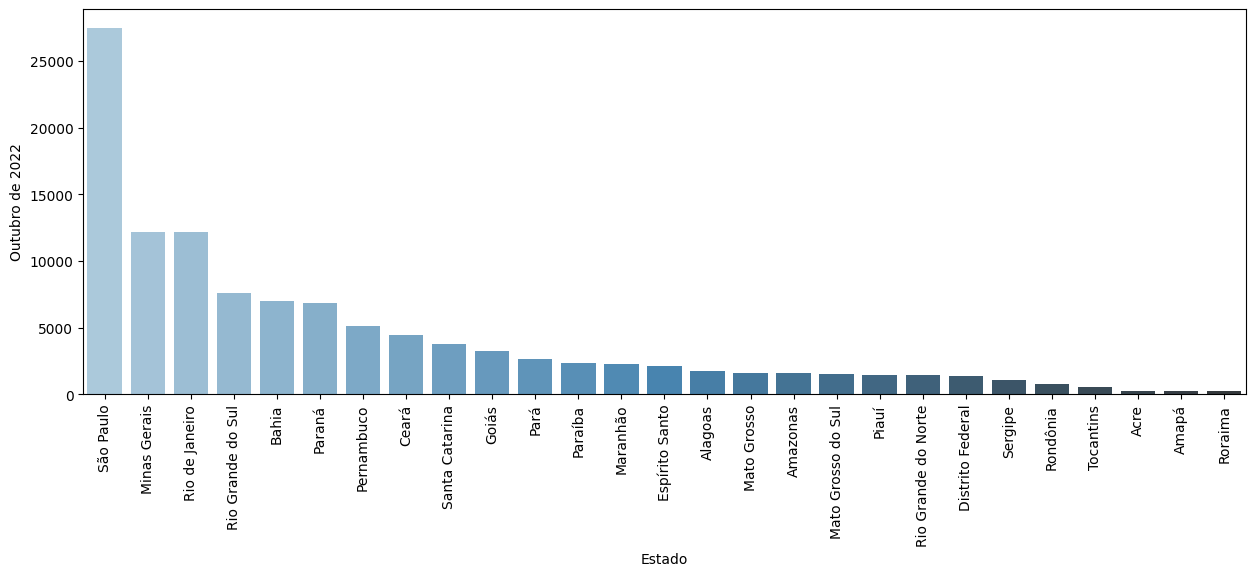

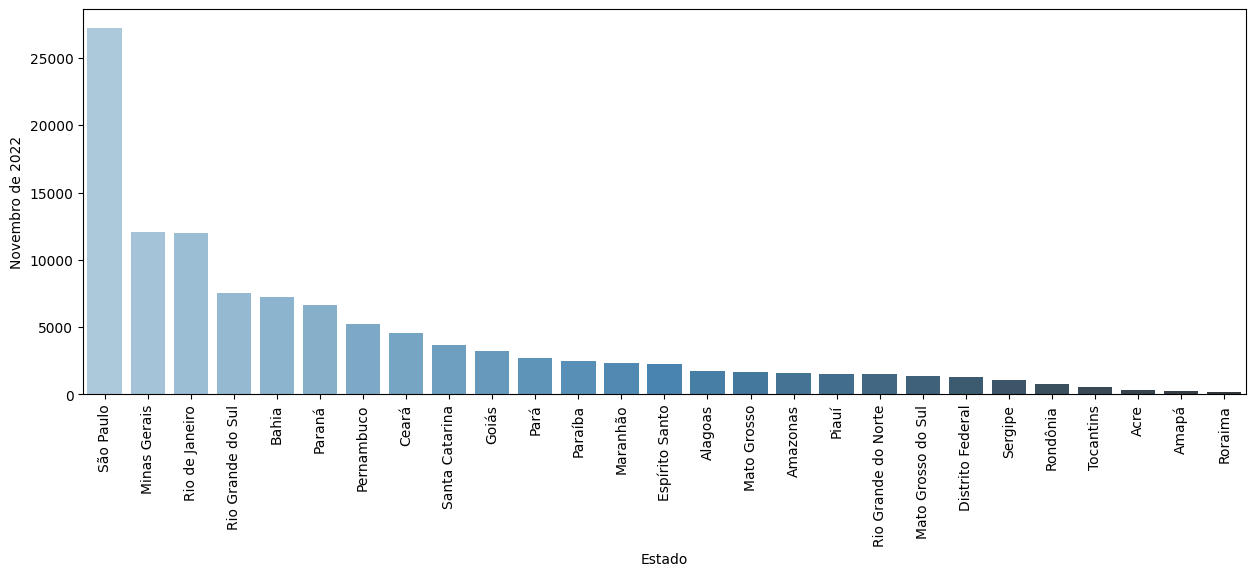

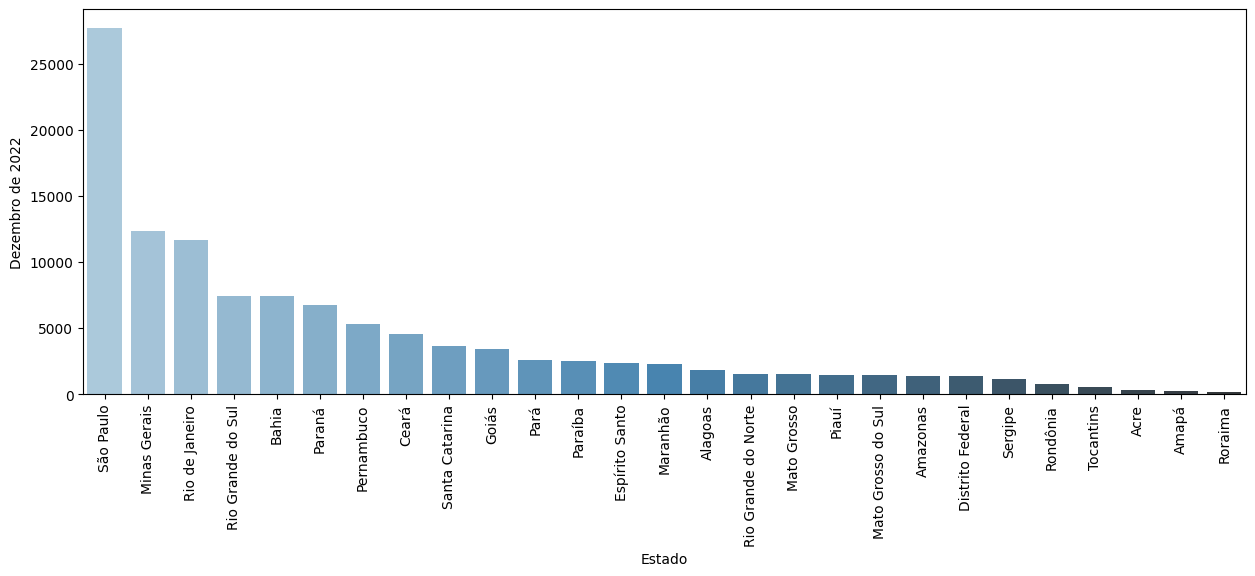

In [14]:
for i in Ano2022['Mês'].unique():
  mês = Ano2022[Ano2022['Mês']==i]
  mês = mês[['Estado', 'Total_mensal_por_ano']].drop_duplicates()
  fig, ax = plt.subplots(figsize=(15,5))
  sns.barplot(data=mês, x='Estado', y='Total_mensal_por_ano', order=mês.sort_values('Total_mensal_por_ano', ascending=False).Estado,palette='Blues_d') # ordenar baseado nos valores de y, e considerando o x
  ax.tick_params(axis='x', rotation=90)
  ax.set_ylabel(f'{i} de 2022')
